## Задание: (10 баллов)

Напишите класс, который реализует автоматическую трансформацию числовых колонок произвольного датафрейма в распределения,
    похожие на нормальные, после чего нормализует (см. семинар по предобработке). Класс должен автоматически для каждой колонки обучающей выборки (метод `fit`) определять, какая именно трансформация ей требуется, чтобы "превратиться в нормальную". Далее, в методе `transform` класс производит все необходимые трансформации + нормализацию для произвольной выборки. Ваш класс в рамках этого задания должен уметь работать со следующими распределениями:
- похожее на нормальное (только нормализация)
- мультимодальное (только нормализация)
- скошенное влево (обычно и сильно)
- скошенное вправо (обычно и сильно)
- равномерное
- "категориальное" (см. аргумент `cat_thr`)

Старайтесь подбирать трансформации из элементарных функций. Вы можете спрашивать LLM, как отличить одно распределение от другого. Вам пригодятся различные статистические показатели/тесты, в которые вы еще не проходили, но такова жизнь. Вы также можете попросить LLM написать вам этот класс, однако не ждите, что он будет работать хорошо с первого раза, придется дебажить каждый конкретный случай. Для написания кода рекомендую Qwen-Coder.

В файле `distributions.csv` лежат данные каждого типа, чтобы проверить себя. При сдаче работы выведите в левом столбике оригинальные данные (обычная и лог шкалы), а в правом -- после трансформации + нормализации (с флагом `use_quantile_transformer=False`), аналогично тому, как мы делали на семинаре. Без визуализации вы получите 0 баллов. Задание будет оцениваться субъективно на похожесть на нормальное распределение. За излишнее использование QuantileTransformer буду штрафовать. Пишите читаемый и аккуратный код. Удачи!

Шаблон с указанием необходимых параметров на вход (свои добавлять можно):

In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, QuantileTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats
import scipy
import numpy as np


# чтобы  руками не перегружать ненужное
class FeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, scaler='StandardScaler', use_quantile_transformer=False, cat_thr=10):
        '''
        scaler: str in ('StandardScaler', 'MinMaxScaler', 'MaxAbsScaler', 'RobustScaler') or None
            -- вариант нормализации данных после трансформаций. None -- без нормализации.

        use_quantile_transformer: Если True, то в случаях, когда мы затрудняемся определить подходящую трансформацию из элементарных функций,
            используем sklearn.preprocessing.QuantileTransformer. Если False, то для таких колонок не используем трансформацию.

        cat_thr: если в колонке количество уникальных значений < cat_thr,
            мы ее считаем за категориальную и не трансформируем (нормализацию делаем)
        '''
        match scaler:
            case "StandarScaler":
                self.scaler = StandardScaler()
            case "MinMaxScaler":
                self.scaler = MinMaxScaler()
            case "RobustScaler":
                self.scaler = RobustScaler()
            case "MaxAbsScaler":
                self.scaler = MaxAbsScaler()
            case _:
                self.scaler = None

        self.cat_thr = cat_thr
        self.use_quantile_transformer = use_quantile_transformer

    def fit(self, X, *args, **kwargs):
        '''
        "Обучаем" наш трансформатор -- собираем все необходимые данные на обучающей выборке, напр. mean, std для StandardScaler,
            а также "записываем", какую трансформацию нужно применить к каждой колонке
        '''
        n_unique = X.nunique()
        cat_idx = (n_unique < self.cat_thr)
        cat_columns = X.columns[cat_idx]
        num_columns = X.columns[~cat_idx]

        weird_columns = []
        alpha = 0.01

        def to_normal(data):
            cdf = stats.ecdf(data).cdf.evaluate
            uniform_data = cdf(data)

            eps = 1e-3
            uniform_data *= 1 - 2 * eps
            uniform_data += eps

            normal_data = stats.norm.ppf(uniform_data)

            df = pd.DataFrame({data.name: normal_data})
            return df

        funcs = []

        for column in num_columns:
            data = df[column]
            normal_data = to_normal(data)
            pvalue = stats.kstest(normal_data, 'norm').pvalue
            if pvalue < alpha:
                weird_columns.append(column)
            else:
                funcs.append(
                    (f"{column}_to_normal", FunctionTransformer(to_normal), column)
                )

        num_columns = [
            column for column in num_columns if column not in weird_columns]

        self.transformer = ColumnTransformer(
            funcs + ([
                ('weird', QuantileTransformer(), weird_columns)
            ] if self.use_quantile_transformer else []),
            remainder='passthrough',
            verbose_feature_names_out=False
        ).set_output(transform='pandas')

        if self.scaler:
            self.transformer = Pipeline([
                ('transform', self.transformer),
                ('scale', self.scaler)
            ], verbose_feature_names_out=False).set_output(transform='pandas')

        self.transformer.fit(X)
        return self

    def transform(self, X, *args, **kwargs):
        '''
        Применяем "записанные" трансформации + нормализацию на все необходимые колонки

        returns:
            X_transformed -- датафрейм размерности X, где все числовые колонки трансформированы (если надо) (+ нормализованы)
        '''
        return self.transformer.transform(X)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv('./distributions(1).csv')

In [4]:
tr = FeatureTransformer(scaler=None, use_quantile_transformer=False, cat_thr=50)

In [5]:
df_tr = tr.fit_transform(df)

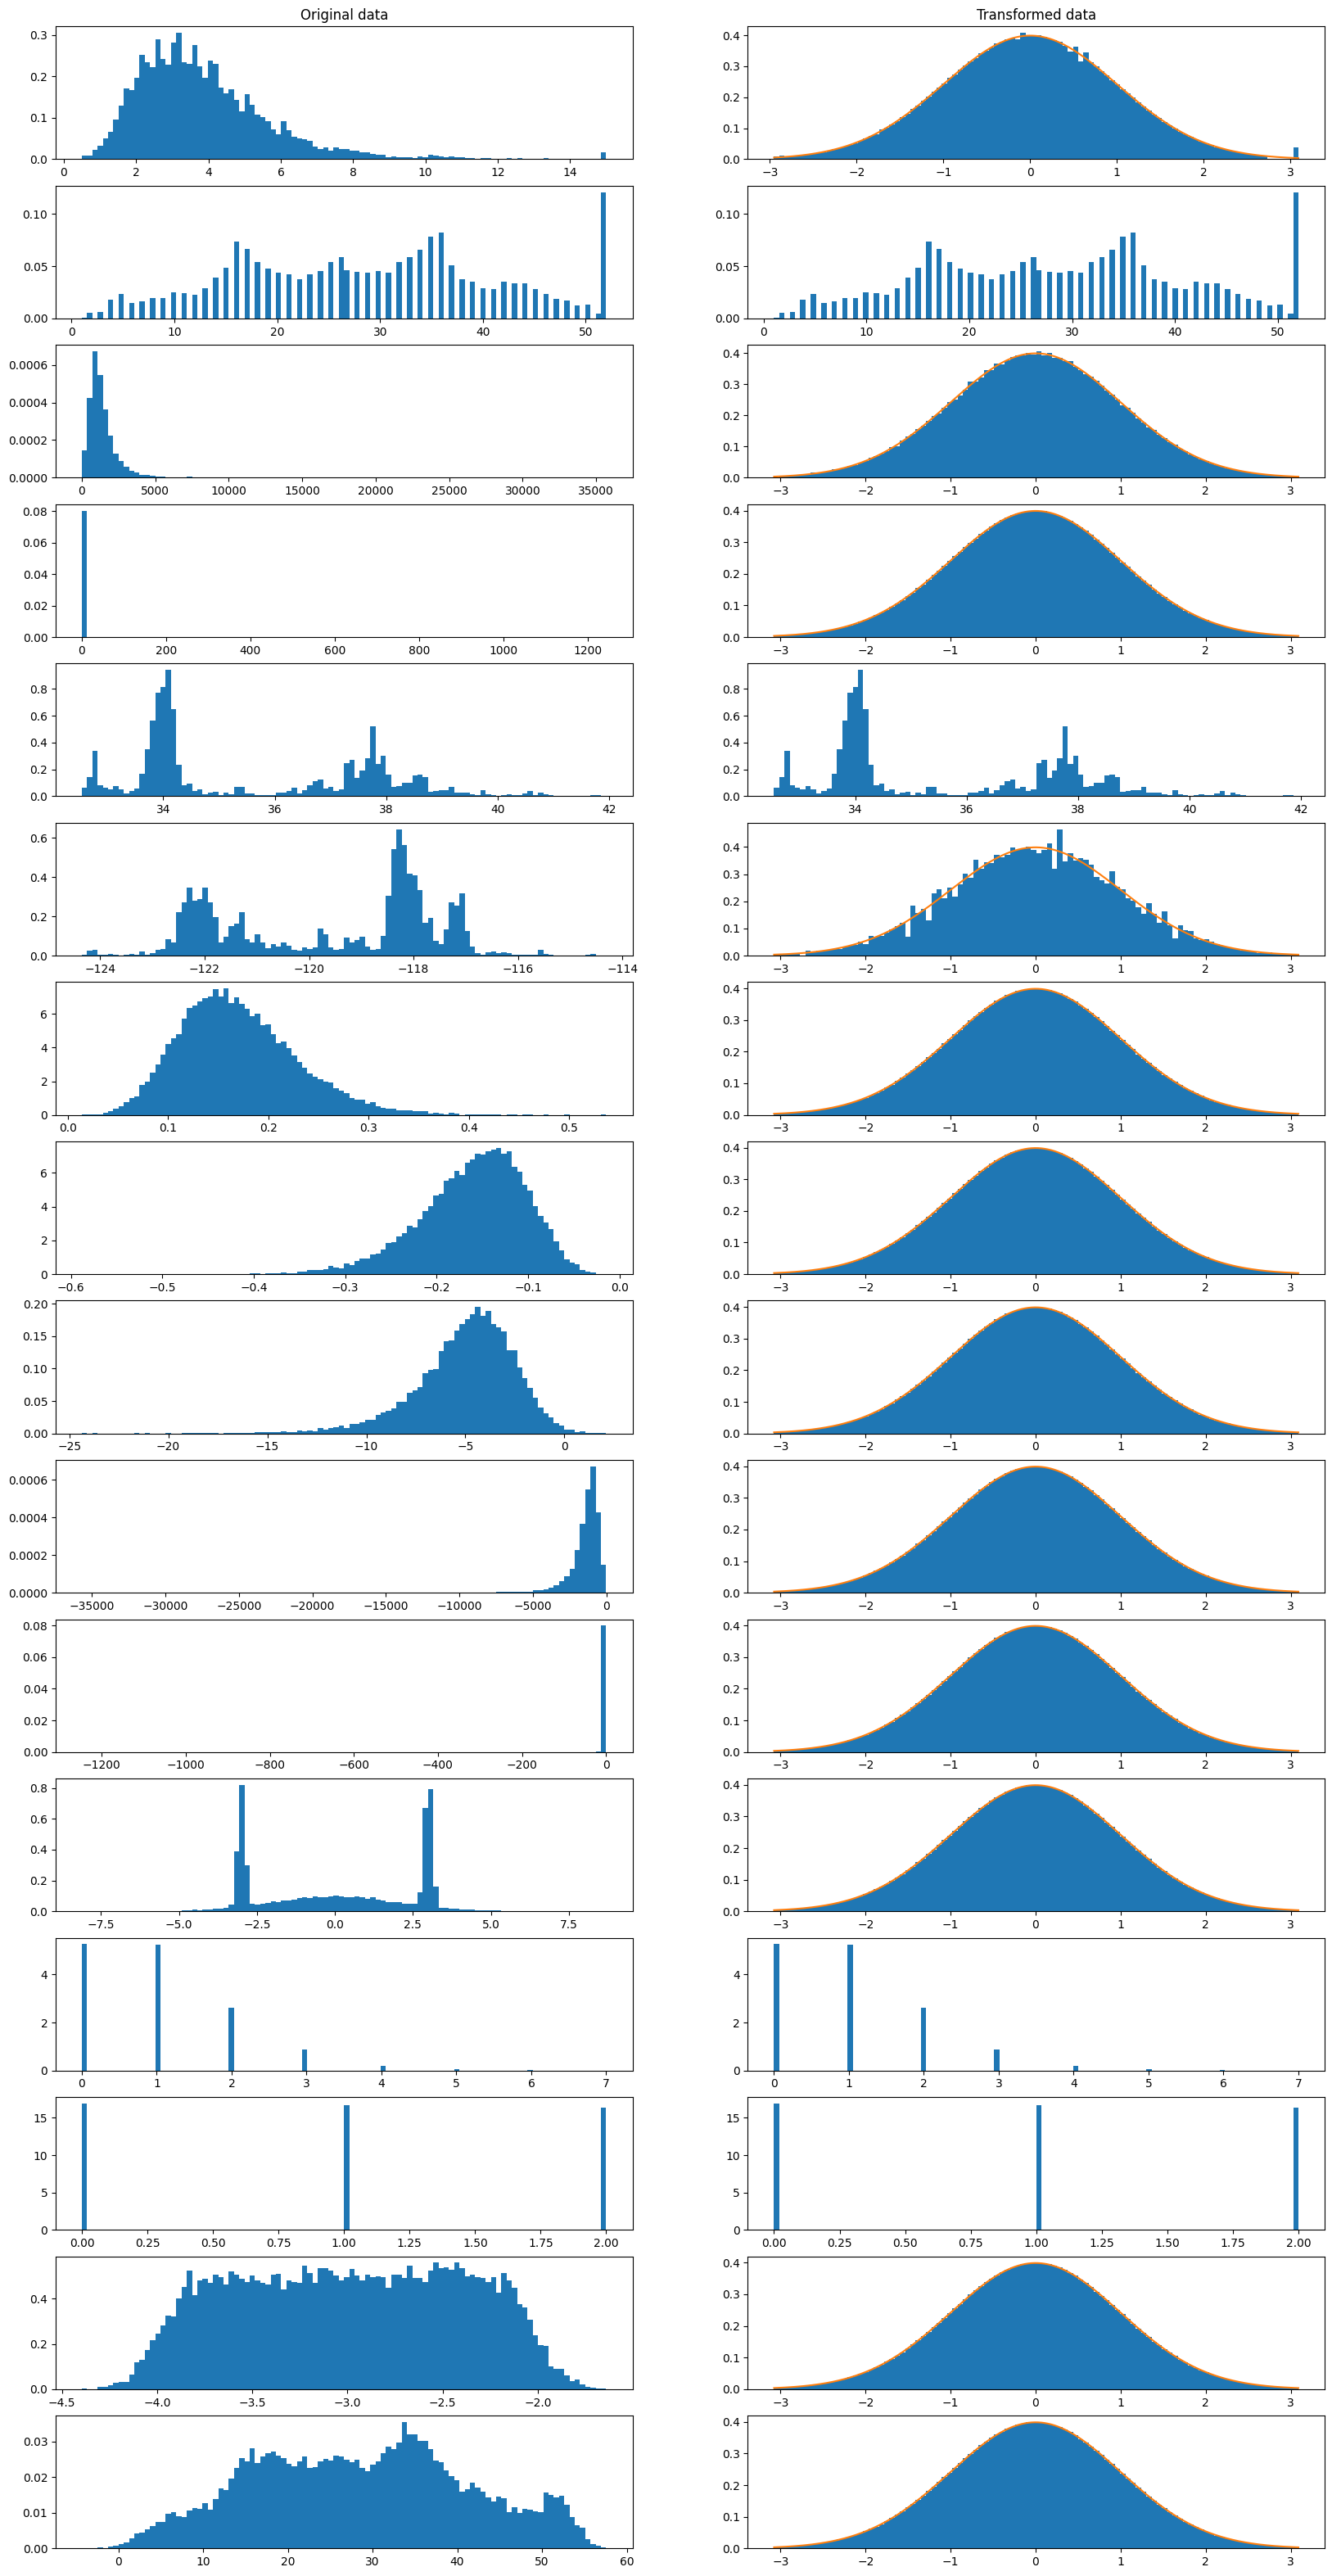

In [6]:
fig, axs = plt.subplots(len(df.columns), 2, figsize=(20, 40))

axs[0, 0].set_title('Original data')
axs[0, 1].set_title('Transformed data')

for i, column in enumerate(df.columns):    
    axs[i, 0].hist(df[column], bins=100, density=True)

    data = df_tr[column]
    pvalue = stats.kstest(data, 'norm').pvalue
    axs[i, 1].hist(df_tr[column], bins=100, density=True)

    if pvalue > 0.01:
        x = np.linspace(np.min(data), np.max(data), 10000)
        y = stats.norm.pdf(x)
        axs[i, 1].plot(x, y)